### Dependencies

In [159]:
# !pip install arch

In [160]:
import arch
print(arch.__version__)

8.0.0


In [161]:
import yfinance as yf
import pandas as pd
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf, adfuller
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA

from arch import arch_model

### Import S&P 500 Data

In [162]:
# test on 10 year data
ticker = "^GSPC"
start_interval = "2016-12-01"
end_interval = "2026-01-01"
interval = "1d"

raw_data_snp500 = yf.Ticker(ticker).history(start=start_interval, end=end_interval, interval=interval)
# raw_data_snp500.index = raw_data_snp500.index.date
raw_data_snp500.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2016-12-01 00:00:00-05:00,2200.169922,2202.600098,2187.439941,2191.080078,5067470000,0.0,0.0
2016-12-02 00:00:00-05:00,2191.120117,2197.949951,2188.370117,2191.949951,3782370000,0.0,0.0
2016-12-05 00:00:00-05:00,2200.649902,2209.419922,2199.969971,2204.709961,3898530000,0.0,0.0
2016-12-06 00:00:00-05:00,2207.260010,2212.780029,2202.209961,2212.229980,3857290000,0.0,0.0
2016-12-07 00:00:00-05:00,2210.719971,2241.629883,2208.929932,2241.350098,4504070000,0.0,0.0


In [163]:
raw_data_snp500.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,2283.000000,2283.000000,2283.000000,2283.000000,2.283000e+03,2283.0,2283.0
mean,3940.732887,3961.871904,3917.977361,3941.377516,4.173998e+09,0.0,0.0
std,1233.092733,1238.519593,1227.102136,1233.267465,1.047905e+09,0.0,0.0
min,2191.120117,2197.949951,2187.439941,2191.080078,0.000000e+00,0.0,0.0
25%,2830.685059,2844.569946,2815.930054,2832.954956,3.510685e+09,0.0,0.0
50%,3888.570068,3918.500000,3859.889893,3899.379883,3.945210e+09,0.0,0.0
75%,4588.760010,4608.655029,4566.375000,4589.169922,4.638880e+09,0.0,0.0
max,6936.020020,6945.770020,6921.600098,6932.049805,9.976520e+09,0.0,0.0


In [164]:
raw_data_snp500.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2283 entries, 2016-12-01 00:00:00-05:00 to 2025-12-31 00:00:00-05:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          2283 non-null   float64
 1   High          2283 non-null   float64
 2   Low           2283 non-null   float64
 3   Close         2283 non-null   float64
 4   Volume        2283 non-null   int64  
 5   Dividends     2283 non-null   float64
 6   Stock Splits  2283 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 142.7 KB


In [165]:
snp500_close = raw_data_snp500["Close"]
snp500_returns = np.log(snp500_close / snp500_close.shift(1)) # log returns -> transform data to weak stationarity

snp500_returns.dropna(inplace=True)
snp500_returns.info()

<class 'pandas.Series'>
DatetimeIndex: 2282 entries, 2016-12-02 00:00:00-05:00 to 2025-12-31 00:00:00-05:00
Series name: Close
Non-Null Count  Dtype  
--------------  -----  
2282 non-null   float64
dtypes: float64(1)
memory usage: 35.7 KB


## 1. Data Exploration

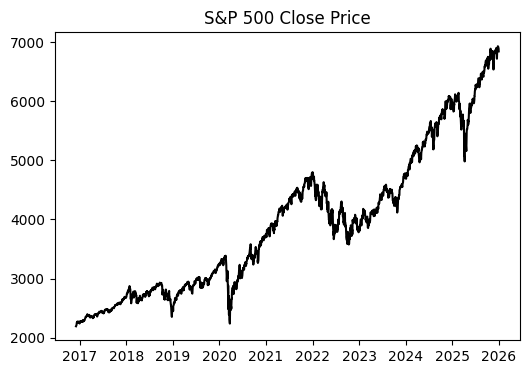

In [166]:
"""
  The price series exhibits non-stationarity with a clear upward trend and time-varying variance
"""

plt.figure(figsize=(6, 4))
plt.plot(snp500_returns.index, snp500_close[1:], c="black")
plt.title("S&P 500 Close Price")
plt.show()

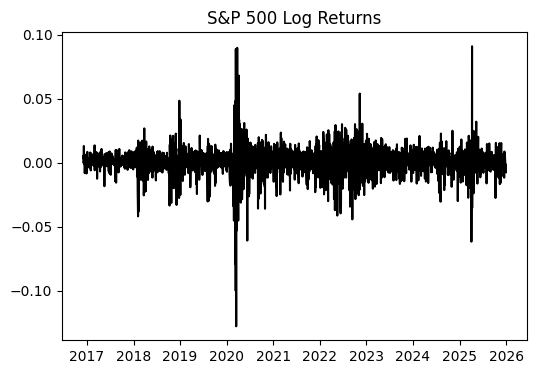

In [167]:
"""
  The log return series fluctuates around a constant mean showing a weak-stationarity characteristics
  and volatility clustering but also conditional heteroskedasticity
"""

plt.figure(figsize=(6, 4))
plt.plot(snp500_returns.index, snp500_returns, c="black")
plt.title("S&P 500 Log Returns")
plt.show()

### 1.1 KDE

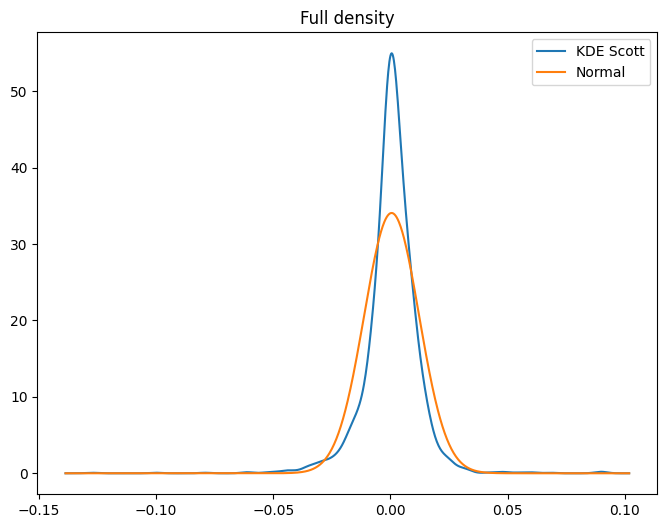

In [168]:
k = 3
std = snp500_returns.std()
mu = snp500_returns.mean()
snp500_returns_numpy = snp500_returns.to_numpy()

data_min = snp500_returns_numpy.min()
data_max = snp500_returns_numpy.max()
padding = 0.05 * (data_max - data_min)

xmin = data_min - padding
xmax = data_max + padding

x = np.linspace(xmin, xmax, 1000)
kde = stats.gaussian_kde(snp500_returns_numpy)

# theoretical samples
norm = stats.norm(
    loc=mu,
    scale=std,
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(x, kde(x), label="KDE Scott")
ax.plot(x, norm.pdf(x), label="Normal")
ax.set_title("Full density")
ax.legend()

plt.show()

### 1.2 QQ plot comparison

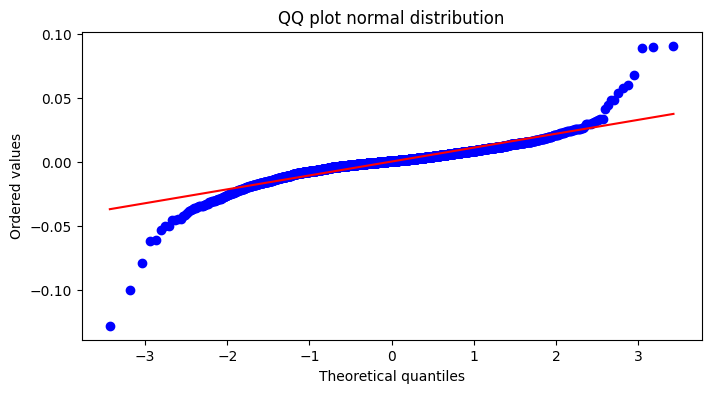

In [169]:
fig, ax = plt.subplots(figsize=(8, 4))

res = stats.probplot(snp500_returns, plot=ax)
ax.set_title("QQ plot normal distribution")
ax.set_ylabel("Ordered values")
ax.set_xlabel("Theoretical quantiles")
plt.show()

In [170]:
kurtosis = stats.kurtosis(snp500_returns)
skew = stats.skew(snp500_returns)

print(f"Kurtosis : {kurtosis}\nSkewness : {skew}")

Kurtosis : 16.51553624296274
Skewness : -0.6899740916066112


### Analysis
- From the EDA above, especially for the distribution block, the S&P 500 returns over 15 years consistently displays **non-gaussian distribution.**

- The heavy tails from the kurtosis and qq plot analysis shows that the data follows a **fat-tailed distribution** which is common in finance.

- The shape parameter shows that the data is **slightly left-skewed**
- Fitting a **t-distribution** would be a better fitting than gaussian distribution

### 1.3 Autocorrelation, White Noise, and Stationarity Analysis
A process $\{Y_t\}$ is weakly stationary if

$$
\begin{aligned}
E(Y_t) &= \mu && \text{(a finite constant for all } t\text{)} \\
\mathrm{Var}(Y_t) &= \sigma^2 && \text{(a positive finite constant for all } t\text{)} \\
\mathrm{Cov}(Y_t, Y_s) &= \gamma(t - s) && \text{for all } t,s
\end{aligned}
$$


A weak white noise process is weakly stationary with :

$$
\mathbb{E}(Y_t) = \mu
$$

$$
\operatorname{Var}(Y_t) = \sigma^2
$$

$$
\operatorname{Cov}(Y_t, Y_s) = 0 \quad \text{for } t \ne s
$$

so that

$$
\gamma(0) = \sigma^2, \qquad \gamma(h) = 0 \text{ for } h \ne 0
$$

$$
\rho(0) = 1, \qquad \rho(h) = 0 \text{ for } h \ne 0
$$


#### Analysis
The Ljung–Box test tends to reject the $$H_0: \rho(1) = \rho(2) = \;...\; = \rho(m) = 0 $$ in large samples because its power increases with sample size, so even very small autocorrelations can produce a large test statistic and lead to rejection.

$$
Q(m) = n(n+2) \sum_{j=1}^{m} \frac{\hat{\rho}_j^2}{n - j}
$$

where

$$
\hat{\rho}_j \text{ is the sample autocorrelation at lag } j,\quad
m \text{ is the number of lags},\quad
n \text{ is the sample size.}
$$

The test rejects the null hypothesis of no serial correlation if

$$
Q(m) > \chi^2_{1-\alpha,\; \text{df}},
$$

with

$$
\text{df} =
\begin{cases}
m, & \text{for a raw series}, \\
m - p - q, & \text{for ARMA residuals}.
\end{cases}
$$

The p-value is computed as

$$
p = 1 - F_{\chi^2_{\text{df}}}\big(Q(m)\big).
$$

It shows that the 10 year return series **doesnt exhibit white noise**

In [171]:
"""
  Ljungbox test is for simulataneous hypothesis testing for autocorrelation.
  In other words it could be used as a white noise test, with the fact that to be characterized
  as a white noise, the p(h) must be 0 for all |h| != 0
"""

ljungbox_test = sm.stats.acorr_ljungbox(snp500_returns, lags=np.arange(1, 11), return_df=True)
ljungbox_test


,lb_stat,lb_pvalue
1,50.430290,1.234737e-12
2,74.045959,8.339198e-17
3,76.301358,1.906166e-16
4,85.369219,1.266596e-17
5,91.239701,3.688462e-18
6,118.603886,3.200703e-23
7,165.830279,1.899123e-32
8,201.837699,2.619624e-39
9,250.396665,8.226567e-49
10,256.976449,1.849865e-49


#### Analysis
1. The ACF plot decays rapildy towards zero as the lag increase, which is consistent with a **stationary process** and rules out unit-root-type non-stationarity

2. The PACF is just to show the direct correlation between $$X_t \;and\; X_{t-k} $$ after removing the linear effects of intermediate lags, and is primarily examined for identifying potential AR structures.

In [172]:
acf_values = acf(snp500_returns)
acf_values

array([ 1.        , -0.14856021,  0.1016393 , -0.03140349, -0.06295402,
        0.05064219, -0.10931293,  0.14357447, -0.12533875,  0.14552197,
       -0.0535555 ,  0.00941284,  0.01726388, -0.07241463,  0.05096801,
       -0.08461618,  0.06015881, -0.03703181,  0.03762492, -0.0090314 ,
       -0.01820535,  0.03906214, -0.07919226,  0.00838141, -0.02912542,
       -0.0161425 , -0.0401088 ,  0.03698955,  0.01914431, -0.01045928,
       -0.00376795, -0.03327724,  0.00159353, -0.01516381])

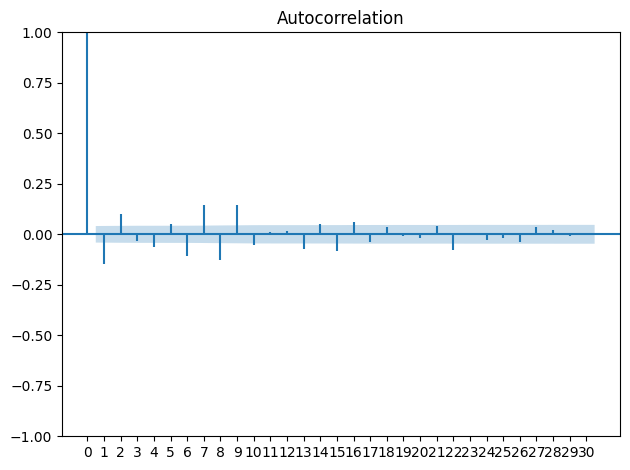

In [173]:
plot_acf(snp500_returns, lags=30, marker=None)
plt.xticks(np.arange(0, 31, 1))
plt.tight_layout()
plt.show()

In [174]:
pacf_values = pacf(snp500_returns)
pacf_values

array([ 1.00000000e+00, -1.48625340e-01,  8.14378895e-02, -5.61336727e-03,
       -7.86333261e-02,  3.61030347e-02, -8.82042639e-02,  1.11439791e-01,
       -8.31816655e-02,  1.06483699e-01, -1.85779158e-02,  1.31496582e-03,
       -1.41835891e-03, -3.16567825e-02, -3.27065258e-03, -3.00378870e-02,
        3.54155771e-03,  8.19147443e-04,  1.54046454e-02, -1.04877965e-02,
       -4.53825742e-03,  1.42593159e-02, -4.20806027e-02, -3.67648038e-02,
       -2.64563695e-04, -3.52476865e-02, -4.97110919e-02,  3.47396663e-02,
        1.63981584e-02,  2.69078394e-03, -2.99174191e-02, -1.58800129e-02,
       -6.40821962e-03, -2.32572747e-03])

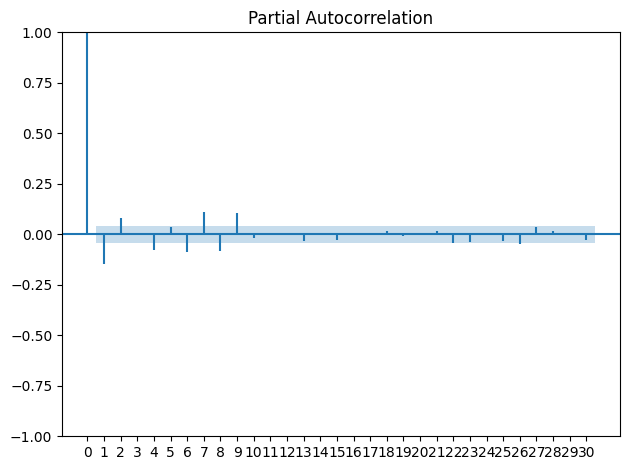

In [175]:
plot_pacf(snp500_returns, lags=30, marker=None)
plt.xticks(np.arange(0, 31, 1))
plt.tight_layout()
plt.show()

In [176]:
snp500_returns_second_order_diff = snp500_returns.diff().dropna()
snp500_returns_second_order_diff

Date
2016-12-05 00:00:00-05:00    0.005407
2016-12-06 00:00:00-05:00   -0.002399
2016-12-07 00:00:00-05:00    0.009672
2016-12-08 00:00:00-05:00   -0.010920
2016-12-09 00:00:00-05:00    0.003764
                               ...   
2025-12-24 00:00:00-05:00   -0.001324
2025-12-26 00:00:00-05:00   -0.003521
2025-12-29 00:00:00-05:00   -0.003194
2025-12-30 00:00:00-05:00    0.002122
2025-12-31 00:00:00-05:00   -0.006008
Name: Close, Length: 2281, dtype: float64

#### Stationary test (Augmented Dicker Fuller & Unit Roots Test)

The ADF test rejects all the null hypotheses at different critical values levels, indicating **strong stationarity.**

The "ct" argument is to set that trend exists, which is true for our 10 year S&P 500 daily return.

$$
\begin{aligned}
H_0 &: \text{Unit root exists (non-stationary)} \\
H_1 &: \text{Unit root does not exist (stationary)} \\[6pt]
\text{Reject } H_0 &\text{ if test statistic } < \text{ critical value}
\end{aligned}
$$


In [177]:
adf_test  = adfuller(snp500_returns, maxlag=10, regression="ct")

adf_statistic = adf_test[0]
critical_values = adf_test[4]

print(f"ADF Test Statistic: {adf_statistic}")
print(f"1% Critical Value: {critical_values['1%']}")
print(f"5% Critical Value: {critical_values['5%']}")
print(f"10% Critical Value: {critical_values['10%']}")

ADF Test Statistic: -15.104483031288936
1% Critical Value: -3.962758399817579
5% Critical Value: -3.4124232970282686
10% Critical Value: -3.128188289100094


### Volatility modeling

#### Conditional Mean Modeling using Autoregressive Model


In [178]:
snp500_returns.index = pd.DatetimeIndex(snp500_returns).to_period("d")

C:\Users\User\AppData\Local\Temp\ipykernel_22716\1797510518.py:1: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  snp500_returns.index = pd.DatetimeIndex(snp500_returns).to_period("d")


In [212]:
"""
  Since the S&P500 log returns first order difference shows a stationary process by the ADF test,
  we dont need to do another differencing again. But the ACF plot still shows some unexplained correlations in the lags
  (could maybe due to sampling bias).
  Which shows that dependence still exists, which is natural. That might be "explained" by an autoregressive model.

  Its important to diagnose the AR models before moving to GARCH, since it would explained
  the conditional mean under the constant variance assumption.
"""

"""
  for simple diagnostic, we could see significants ACF from 1 - 2 lags but insignificant at p = 3, so
  we could diagnose using p = 3, we see that the z-tests reject the H0 : phi = 0 and H0 : c = 0 where is the B_0 -> intercept
  at lags 1 and 2. But according the ACF plot, at lags = 3, it doesnt have significant ACF and it also shown at the AR
  fitting results which shows that we failed to reject the hypotheses (Note some remaining sample
  correlation must also be considered and the
  significance must also be considered as large samples grows, we could see it by the p-value instead)
"""
res1 = AutoReg(snp500_returns, lags=3).fit()
print(res1.summary())


                            AutoReg Model Results                             
Dep. Variable:                  Close   No. Observations:                 2282
Model:                     AutoReg(3)   Log Likelihood                6933.030
Method:               Conditional MLE   S.D. of innovations              0.012
Date:                Fri, 06 Mar 2026   AIC                         -13856.059
Time:                        15:51:32   BIC                         -13827.402
Sample:                    01-01-1970   HQIC                        -13845.606
                         - 01-01-1970                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.000      2.167      0.030    5.03e-05       0.001
Close.L1      -0.1361      0.021     -6.497      0.000      -0.177      -0.095
Close.L2       0.0806      0.021      3.825      0.0

In [213]:
acf_values_ar1 = acf(res1.resid)
acf_values_ar1

array([ 1.00000000e+00, -5.90309712e-04,  6.33138265e-03, -1.51031553e-02,
       -6.34293057e-02,  2.19391011e-02, -7.42925661e-02,  1.04730311e-01,
       -8.14335995e-02,  1.17513694e-01, -2.74449142e-02, -1.17328373e-03,
        1.07710702e-02, -6.14300602e-02,  2.71023525e-02, -6.56400106e-02,
        4.02803607e-02, -1.85613833e-02,  3.00860774e-02, -7.52456057e-03,
       -1.21977341e-02,  2.88142643e-02, -7.37606025e-02, -7.17436040e-03,
       -2.14902144e-02, -2.99998157e-02, -3.87783401e-02,  3.83504114e-02,
        2.69175997e-02, -9.52045898e-03, -1.11713732e-02, -3.31682621e-02,
       -4.69082530e-03, -1.27275143e-02])

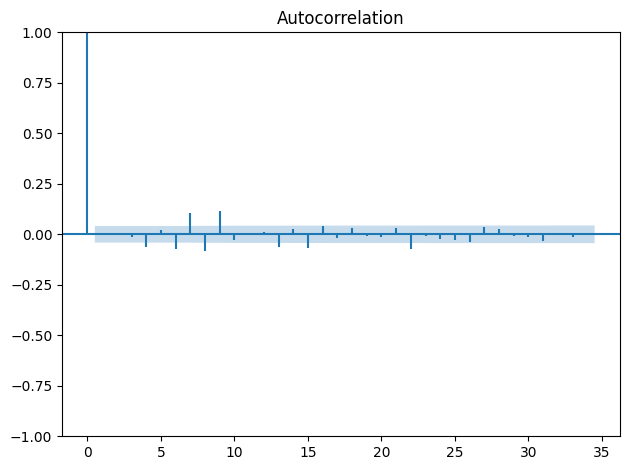

In [214]:
plot_acf(res1.resid, marker=None)
plt.tight_layout()
plt.show()

In [215]:
ljungbox_test = sm.stats.acorr_ljungbox(res1.resid, lags=np.arange(1, 31), return_df=True)
ljungbox_test

,lb_stat,lb_pvalue
1,0.000795,9.775032e-01
2,0.092313,9.548927e-01
3,0.613307,8.933795e-01
4,9.806537,4.381574e-02
5,10.906851,5.325845e-02
6,23.529802,6.371336e-04
7,48.625893,2.685885e-08
8,63.805472,8.309765e-11
9,95.429757,1.317285e-16
10,97.155431,2.018315e-16


In [203]:
"""
  Ok since, the ljung-box test rejects at AR(3) on the residuals, it means that the model isnt the true process.
  Since a correct process would remove all the linear dependance on the residuals.
  Because of that we could try increasing the order lags

  The AIC and BIC finds the optimal balanced model on p = lags
  which finding the best balance between model complexity (parameters) and its performance.
  
  Note that p between AIC and BIC could be different, so its up to us to choose to optimize
  BIC or AIC based on our goals.
"""

optimal_model = {}

for i in range(1, 31):
  res = AutoReg(snp500_returns, lags=i).fit()

  if not optimal_model:
    optimal_model["res_aic"] = res
    optimal_model["res_bic"] = res
    continue

  if optimal_model["res_aic"].aic > res.aic:
    optimal_model["res_aic"] = res

  if optimal_model["res_bic"].bic > res.bic:
    optimal_model["res_bic"] = res

print("=" * 10 + " " + "AIC RESULTS" + " " + "=" * 10)
print(optimal_model["res_aic"].summary())
print()
print("=" * 10 + " " + "BIC RESULTS" + " " + "=" * 10)
print(optimal_model["res_bic"].summary())

========== AIC RESULTS ==========
                            AutoReg Model Results                             
Dep. Variable:                  Close   No. Observations:                 2282
Model:                     AutoReg(9)   Log Likelihood                6965.125
Method:               Conditional MLE   S.D. of innovations              0.011
Date:                Fri, 06 Mar 2026   AIC                         -13908.249
Time:                        15:22:42   BIC                         -13845.232
Sample:                    01-01-1970   HQIC                        -13885.260
                         - 01-01-1970                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.000      2.111      0.035    3.61e-05       0.001
Close.L1      -0.1029      0.021     -4.933      0.000      -0.144      -0.062
Close.L2       0.0

In [204]:
"""
  Now to check whether our model successfully captures all the linear dependance in the regression,
  we need to check any autocorrelation in the estimated residuals (innovations. We do this by
  using the Ljung-Box test. If the Ljung-Box test rejects than that means there are still
  autocorrelation left that our model failed to capture

  Here we could find that our AR(9) models successfully captures all of the linear dependance.
"""

ljungbox_test = sm.stats.acorr_ljungbox(optimal_model["res_aic"].resid, lags=np.arange(1, 31), return_df=True)
ljungbox_test

,lb_stat,lb_pvalue
1,0.009708,0.921514
2,0.017338,0.991368
3,0.030742,0.998580
4,0.035573,0.999844
5,0.040221,0.999983
6,0.087696,0.999986
7,0.141643,0.999992
8,0.205837,0.999996
9,0.403253,0.999988
10,0.868075,0.999910


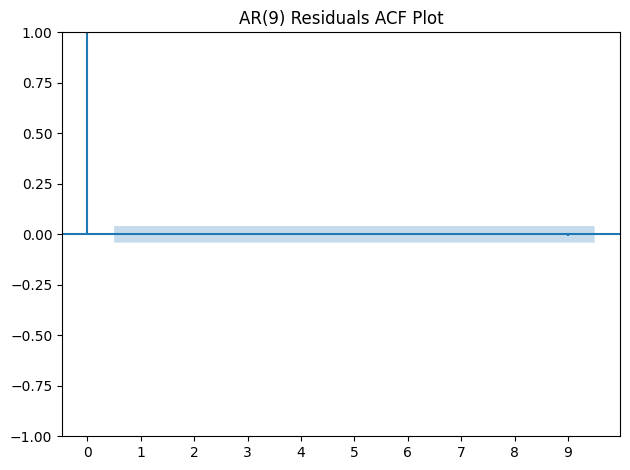

In [185]:
plot_acf(optimal_model["res_aic"].resid, lags=9, marker=None)
plt.xticks(np.arange(0, 10, 1))
plt.tight_layout()
plt.title("AR(9) Residuals ACF Plot")
plt.show()

##### MA(q) Model

In [186]:
"""
Although the AR(9) model successfully captures all linear dependance of the process.
Its not a parsimonious fit. Hence we could try another approach, in finance its common
to use ARMA or ARIMA, but before that we would try fitting the MA(q) model first.

So instead of regressing the data by feeding past data, were regressing the weighted average of the past values
of the white noise process (epsilon_t) instead.
"""

ma_model = ARIMA(snp500_returns, order=(0, 0, 9)) # MA(1)
ma_res = ma_model.fit()
print(ma_res.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2282
Model:                 ARIMA(0, 0, 9)   Log Likelihood                6985.125
Date:                Fri, 06 Mar 2026   AIC                         -13948.251
Time:                        15:16:22   BIC                         -13885.190
Sample:                    01-01-1970   HQIC                        -13925.250
                         - 01-01-1970                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.000      1.844      0.065   -3.14e-05       0.001
ma.L1         -0.0992      0.011     -9.320      0.000      -0.120      -0.078
ma.L2          0.0685      0.010      6.556      0.0

In [187]:
ma_acf_values = acf(ma_res.resid)
ma_acf_values

array([ 1.00000000e+00, -8.93302428e-03,  7.13767695e-03, -4.53877539e-03,
       -2.50871350e-03,  4.01817340e-03, -9.44052805e-03,  1.33015188e-02,
       -1.40357794e-02,  1.55849761e-02, -4.01802951e-02,  9.31165871e-04,
        1.28344309e-02, -5.45736233e-02,  2.18253647e-02, -5.81564970e-02,
        3.85615385e-02, -1.58554539e-02,  2.34959799e-02, -1.21852966e-02,
       -4.82081636e-03,  1.83106267e-02, -5.94870202e-02, -1.50045335e-02,
       -7.70983260e-03, -3.71608342e-02, -4.09589718e-02,  3.28673612e-02,
        2.51450187e-02, -1.10952534e-02, -1.33460971e-02, -2.66090405e-02,
        4.29892518e-03, -1.49589623e-02])

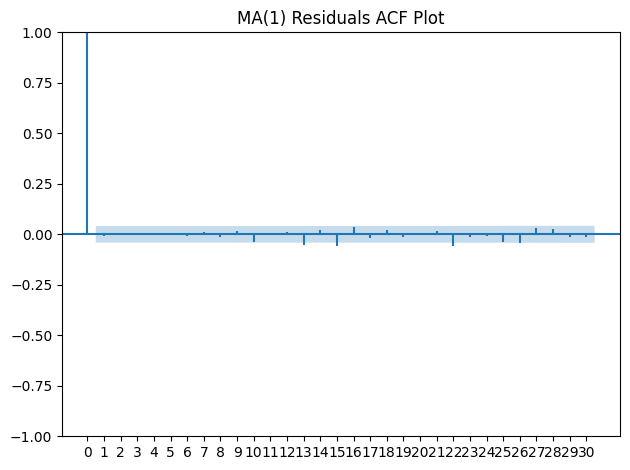

In [188]:
plot_acf(ma_res.resid, lags=30, marker=None)
plt.xticks(np.arange(0, 31, 1))
plt.tight_layout()
plt.title("MA(1) Residuals ACF Plot")
plt.show()

In [189]:
"""
  The MA(9) failed to removes the autocorrelation in the residuals, hence its not better than
  the AR(9) model
"""

ljungbox_test_ma = sm.stats.acorr_ljungbox(ma_res.resid, lags=np.arange(1, 31), return_df=True)
ljungbox_test_ma

,lb_stat,lb_pvalue
1,0.182341,0.669369
2,0.298804,0.861223
3,0.345918,0.951173
4,0.360318,0.985595
5,0.397276,0.995404
6,0.601370,0.996378
7,1.006723,0.994719
8,1.458261,0.993379
9,2.015222,0.991225
10,5.718869,0.838304


##### ARIMA(p, d, q)

In [190]:
"""
  AR still is a better fit for the conditional mean, but we need to try another
  conditional mean modeling which incorporates AR + MA which is called ARMA or ARIMA

  The term "I" in ARIMA means order-differencing, since our first-order differencing of the
  S&P500 log returns already shows a stationary time series by the ADF test, we dont need
  differencing it again.
"""

arima_model = ARIMA(snp500_returns, order=(9, 0, 1)) # base model
arima_result = arima_model.fit()
print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2282
Model:                 ARIMA(9, 0, 1)   Log Likelihood                6995.425
Date:                Fri, 06 Mar 2026   AIC                         -13966.850
Time:                        15:16:24   BIC                         -13898.056
Sample:                    01-01-1970   HQIC                        -13941.758
                         - 01-01-1970                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.000      1.854      0.064   -2.83e-05       0.001
ar.L1         -0.0564      0.124     -0.454      0.650      -0.300       0.187
ar.L2          0.0672      0.019      3.589      0.0

In [191]:
arima_acf_values = acf(arima_result.resid)
arima_acf_values

array([ 1.00000000e+00,  2.03124939e-03, -2.45136709e-03,  3.36582633e-03,
        1.87403393e-03,  1.88593858e-03,  3.49885076e-03, -1.82512631e-03,
        6.49183316e-04, -5.65824307e-03, -1.96783144e-02,  4.82612016e-04,
       -5.13801906e-03, -2.36662530e-02, -2.94261903e-03, -2.83002480e-02,
        9.74711536e-03,  2.51219013e-03,  9.66441483e-03, -1.17130533e-02,
       -6.13952478e-03,  1.70488083e-02, -5.65433249e-02, -1.91099306e-02,
       -4.68031647e-03, -3.93033405e-02, -4.22418134e-02,  3.49379304e-02,
        2.06223829e-02, -6.44160910e-03, -1.81203430e-02, -2.38114991e-02,
        3.34540314e-03, -1.53011117e-02])

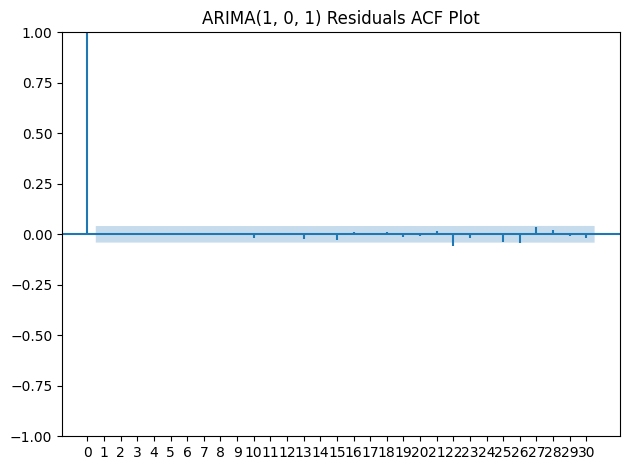

In [192]:
plot_acf(arima_result.resid, lags=30, marker=None)
plt.xticks(np.arange(0, 31, 1))
plt.tight_layout()
plt.title("ARIMA(1, 0, 1) Residuals ACF Plot")
plt.show()

In [193]:
ljungbox_test = sm.stats.acorr_ljungbox(arima_result.resid, lags=np.arange(1, 31), return_df=True)
ljungbox_test

,lb_stat,lb_pvalue
1,0.009428,0.922649
2,0.023165,0.988484
3,0.049074,0.997151
4,0.057109,0.999600
5,0.065251,0.999943
6,0.093285,0.999984
7,0.100917,0.999998
8,0.101883,1.000000
9,0.175296,1.000000
10,1.063636,0.999772


##### Conclusion:
- The AR(9) model is the most appropriate model for the conditional mean since its successfully
captures all the linear dependance due to the fact that its residuals passes the ljung-box test
and showing no autocorrelation left
- The ARMA and MA model arent suitable

#### Conditional Heteroskedasticity

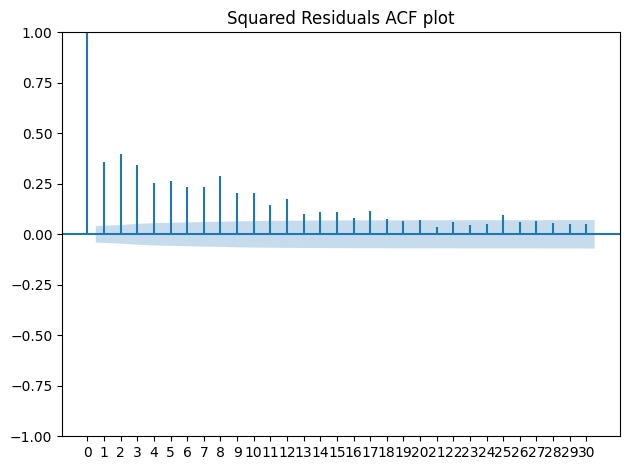

In [224]:
"""
  Since the AR(9) captures the linear dependance, we still need to be cautious because
  the autoregressive model only model the conditional mean under the constant variance
  assumption.

  Especially if we want to model volatility, we would diagnose the autocorrelations of the
  squared-residuals and squared returns instead.
"""

squared_resid = np.square(optimal_model["res_aic"].resid)
squared_returns = np.square(snp500_returns)

plot_acf(squared_resid, lags=30, marker=None)
plt.xticks(np.arange(0, 31, 1))
plt.title("Squared Residuals ACF plot")
plt.tight_layout()
plt.show()

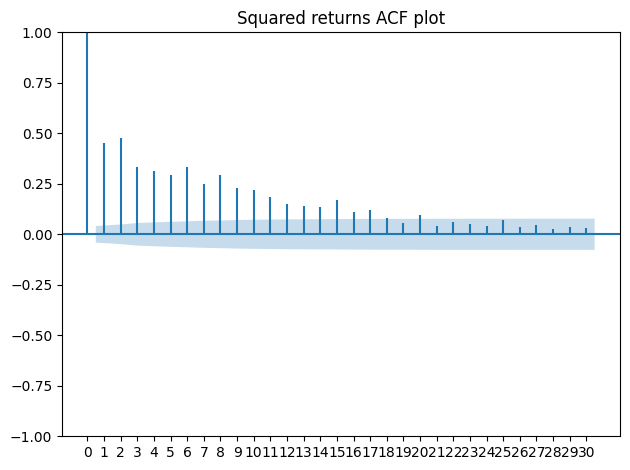

In [225]:
plot_acf(squared_returns, lags=30, marker=None)
plt.xticks(np.arange(0, 31, 1))
plt.title("Squared returns ACF plot")
plt.tight_layout()
plt.show()

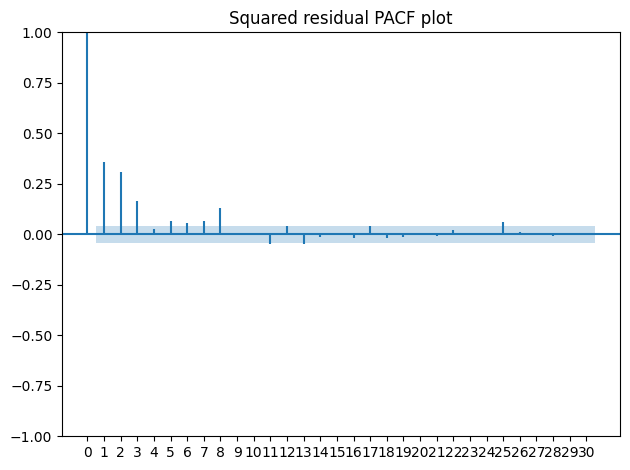

In [228]:
plot_pacf(squared_resid, lags=30, marker=None)
plt.xticks(np.arange(0, 31, 1))
plt.tight_layout()
plt.title("Squared residual PACF plot")
plt.show()

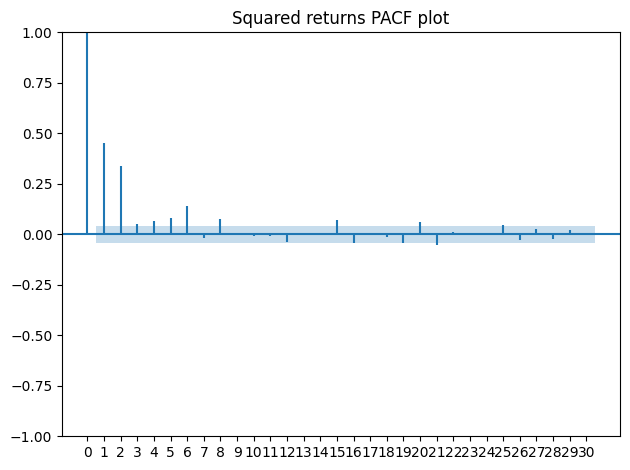

In [229]:
plot_pacf(squared_returns, lags=30, marker=None)
plt.xticks(np.arange(0, 31, 1))
plt.tight_layout()
plt.title("Squared returns PACF plot")
plt.show()

In [ ]:
"""
  Autocorrelation in squared residuals indicates conditional heteroskedasticity.
  which means volatility remain after removing mean dynamics, which is expected.

  Also the slow decay pattern on the squared returns ACF shows that there are 
  volatility clustering which is one the stylized facts in the financial markets that needed
  to be diagnosed.

  The formal test to diagnose conditional heteroskedasticity is through the ARCH-LM that was introduced by Engle
"""

arch_lm_res = sm.stats.diagnostic.het_arch(
  resid=optimal_model["res_aic"].resid,
  nlags=30,
  ddof=9 # since our p for AR = 9
)

print("H0 : a1 = a2 = ... = aq = 0")
print(f"Test-statistic : {arch_lm_res[0]}")
print(f"p-value : {arch_lm_res[1]}")

H0 : a1 = a2 = ... = aq = 0
Test-statistic : 593.070592879036
p-value : 8.052789043501573e-106


In [ ]:
"""
  The ARCH-LM test strongly rejects the hypotheses of constant variance in the residuals.
  Therefore GARCH models are needed to handle conditional variance.
"""

model = arch_model(
  snp500_returns * 100, # scaling purpose
  mean="constant",
  vol="GARCH",
  p=1,
  q=1
)

res = model.fit()
print(res.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 24076.287623453205
Iteration:      2,   Func. Count:     16,   Neg. LLF: 13101.92370041032
Iteration:      3,   Func. Count:     26,   Neg. LLF: 4724.656973293331
Iteration:      4,   Func. Count:     34,   Neg. LLF: 3372.948688386482
Iteration:      5,   Func. Count:     40,   Neg. LLF: 6508.796314042684
Iteration:      6,   Func. Count:     46,   Neg. LLF: 3092.9085396347828
Iteration:      7,   Func. Count:     52,   Neg. LLF: 2967.6291636629376
Iteration:      8,   Func. Count:     58,   Neg. LLF: 2967.685428764517
Iteration:      9,   Func. Count:     64,   Neg. LLF: 2967.405159955949
Iteration:     10,   Func. Count:     69,   Neg. LLF: 2967.405090101869
Iteration:     11,   Func. Count:     73,   Neg. LLF: 2967.405090102526
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2967.405090101869
            Iterations: 11
            Function evaluations: 73
            Gradient evaluations:

In [221]:

# !jupyter nbconvert --to html \
# "/content/drive/MyDrive/Colab Notebooks/eda_01.ipynb" \
# --log-level ERROR